# EDA
    - Author: Santiago Avella. Git hub: https://github.com/TiagoMimi

# Libraries

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as ticker

pd.set_option("display.max_columns", None)

# Load data

In [46]:
script_path = Path.cwd() 
csv_path = script_path.parent/"data"/"mall_medellin_V1.csv" 

df = pd.read_csv(csv_path,
                sep=";")

In [47]:
df["year"] = df["year"].astype(str)

# EDA (One Variable)

## Year

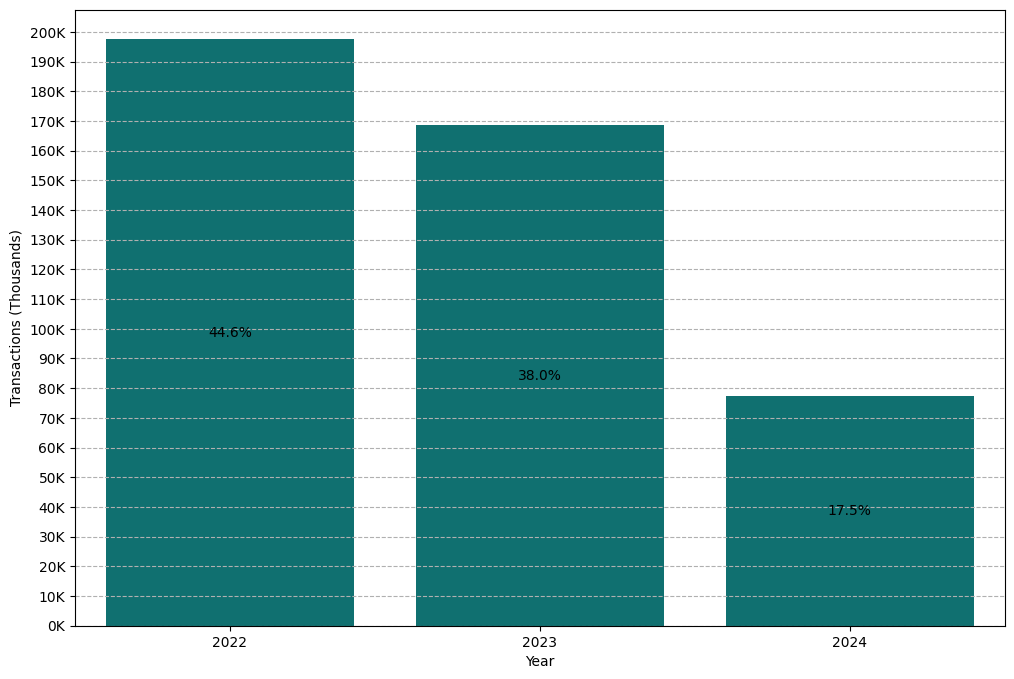

In [48]:
plt.figure(figsize=(12,8))

ax = sns.countplot(
    data=df,
    x="year",
    order=sorted(df["year"].unique()),
    color="teal"
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

plt.yticks(np.arange(0,210000,10000))
plt.ylabel("Transactions (Thousands)")
plt.xlabel("Year")

plt.grid(linestyle="--",
        axis="y")

total = len(df)

for container in ax.containers:
    labels = [
        f"{(bar.get_height() / total) * 100:.1f}%"
        for bar in container
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="center"
    )

plt.show()

plt.show()

## Quarter

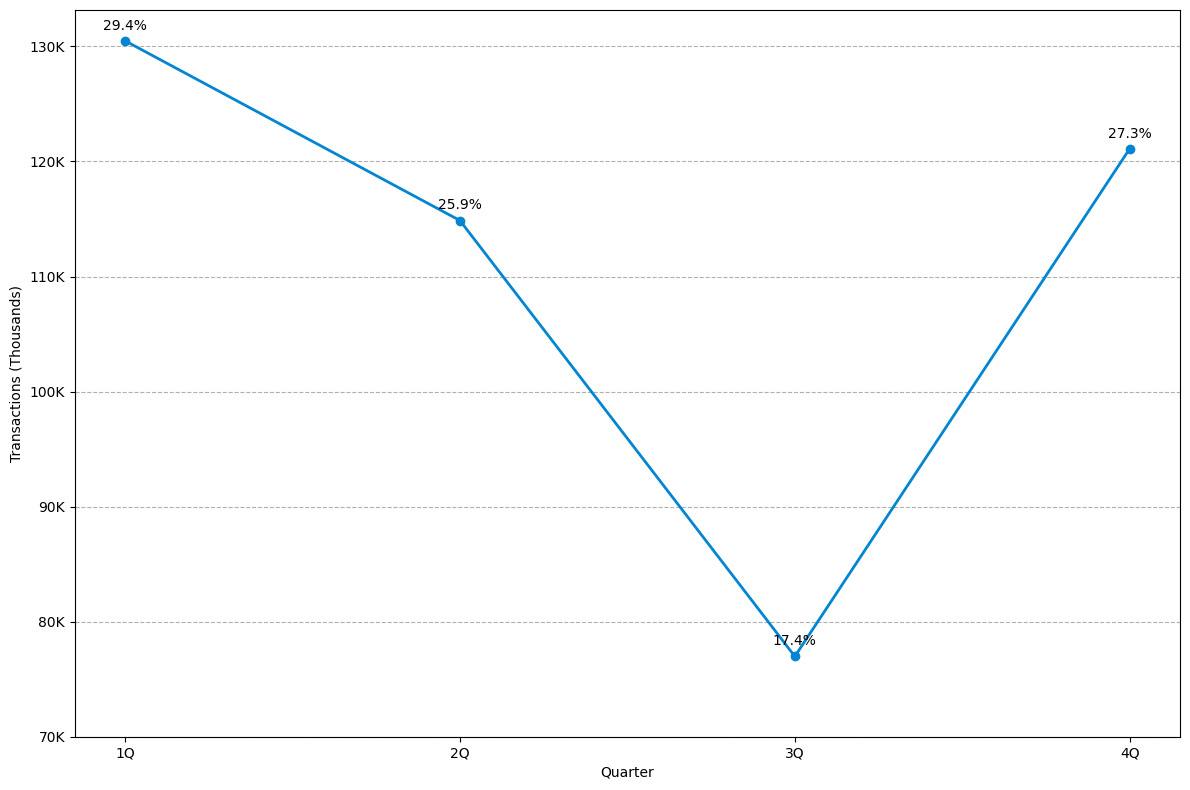

In [49]:
plt.figure(figsize=(12,8))

quarter_count = (
    df["quarter"]
    .value_counts()
    .sort_index()
)

ax = plt.plot(
    quarter_count.index,
    quarter_count.values,
    marker="o",
    linewidth=2,
    color="#0385D1"
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

plt.yticks(np.arange(70000,140000,10000))

plt.ylabel("Transactions (Thousands)")
plt.xlabel("Quarter")

plt.grid(
    linestyle="--",
    axis="y"
)

total = len(df)

# Percentage above each point
for x, y in zip(quarter_count.index, quarter_count.values):
    plt.annotate(
        f"{(y / total) * 100:.1f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.tight_layout()
plt.show()

## Customer Id

In [50]:
print("Number of transactions")
print(len(df))
print("Number of unique clients")
print(df["customer_id"].nunique())
print("Average transactions by clients")
print(round(len(df)/df["customer_id"].nunique(),2))

Number of transactions
443454
Number of unique clients
50939
Average transactions by clients
8.71


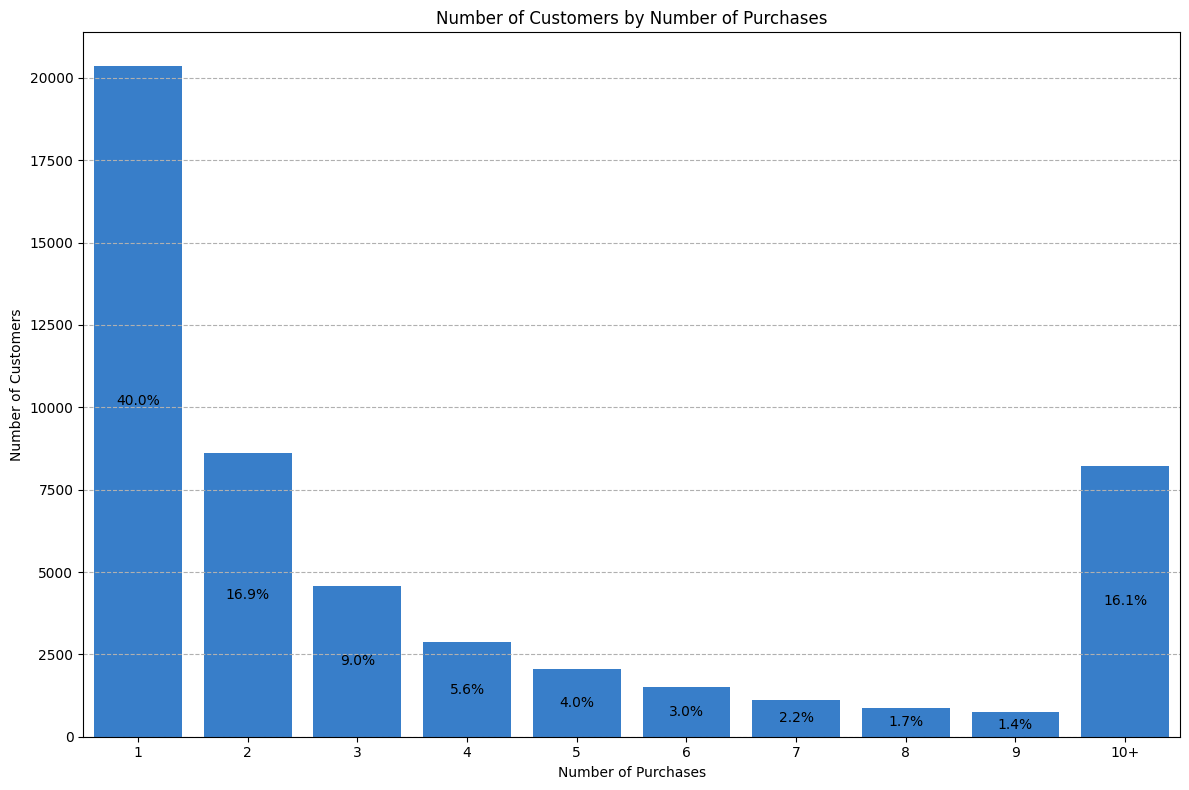

In [51]:
purchases_per_customer = df.groupby("customer_id").size()

purchase_groups = purchases_per_customer.clip(upper=10)

purchase_distribution = purchase_groups.value_counts().sort_index()

purchase_distribution.index = [
    "10+" if x == 10 else str(x)
    for x in purchase_distribution.index
]

plt.figure(figsize=(12, 8))

sns.barplot(
    x=purchase_distribution.index,
    y=purchase_distribution.values,
    color="#207DE1"
)

# Porcentaje dentro de cada barra
total_customers = purchase_distribution.sum()

for i, value in enumerate(purchase_distribution.values):
    percentage = value / total_customers * 100
    
    plt.text(
        i,
        value / 2,
        f"{percentage:.1f}%",
        ha="center",
        va="center"
    )

plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.title("Number of Customers by Number of Purchases")

plt.grid(
    linestyle="--",
    axis="y"
)

plt.tight_layout()
plt.show()

## Purchase_amount

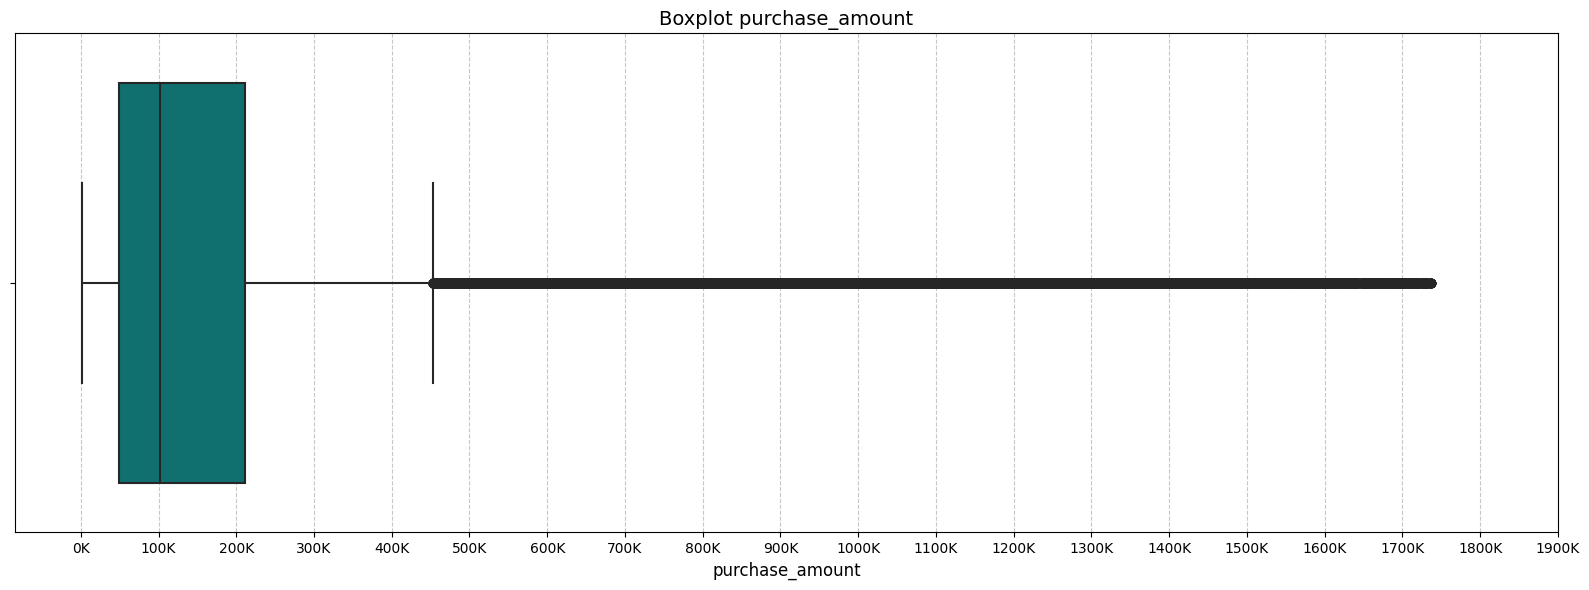

In [52]:
plt.figure(figsize=(16, 6))
sns.boxplot(
    x=df["purchase_amount"],
    color='teal',
    linewidth=1.5
)
plt.title("Boxplot purchase_amount", fontsize=14)
plt.xlabel("purchase_amount", fontsize=12)
plt.grid(axis='x',
        linestyle='--',
        alpha=0.7)

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

plt.xticks(np.arange(0,2000000,100000))
plt.tight_layout()
plt.show()

In [53]:
from scipy.stats import kstest
from scipy.stats import normaltest


# Normal test Pearson
stat, p = normaltest(df["purchase_amount"].dropna())

print("Statistic:", stat)
print("p-value:", p)

# Kolmogorov-Smirnov
stat, p = kstest(
    df["purchase_amount"].dropna(),
    "norm",
    args=(
        df["purchase_amount"].mean(),
        df["purchase_amount"].std()
    )
)

print("Statistic:", stat)
print("p-value:", p)

Statistic: 290368.5110928378
p-value: 0.0
Statistic: 0.2343731721497372
p-value: 0.0


## Business Establishment

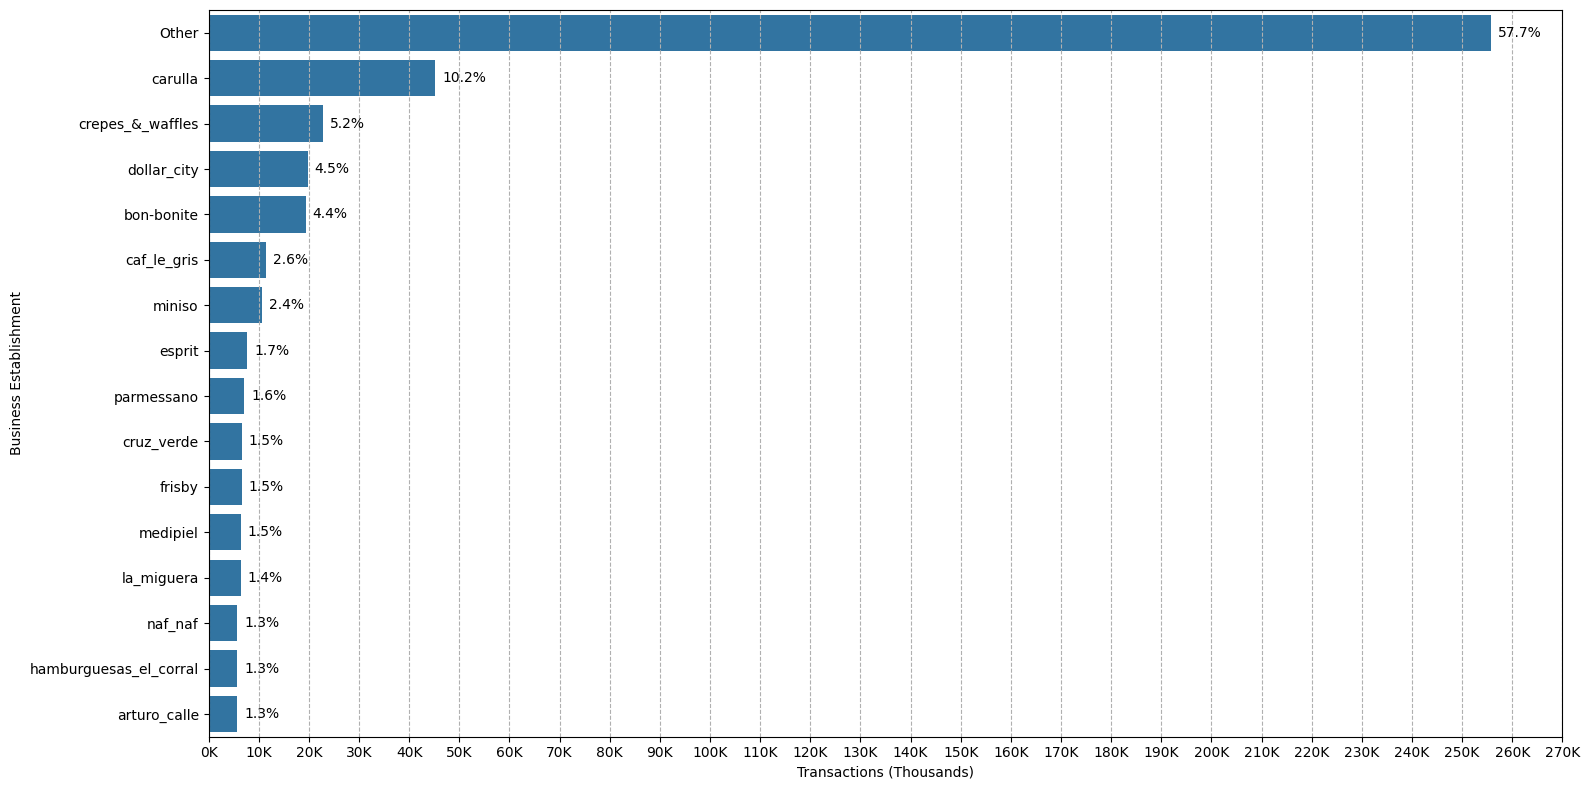

In [54]:
plt.figure(figsize=(16,8))


top_15 = df["business_establishment"].value_counts().head(15).index


df["business_establishment_grouped"] = df["business_establishment"].where(
    df["business_establishment"].isin(top_15),
    "Other"
)


order = df["business_establishment_grouped"].value_counts().index

ax = sns.countplot(
    data=df,
    y="business_establishment_grouped",
    order=order
)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

plt.xticks(np.arange(0,280000,10000))

plt.xlabel("Transactions (Thousands)")
plt.ylabel("Business Establishment")

plt.grid(
    linestyle="--",
    axis="x"
)

total = len(df)


for container in ax.containers:
    labels = [
        f"{(bar.get_width() / total) * 100:.1f}%"
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="edge",
        padding=5
    )

plt.tight_layout()
plt.show()

## Gender

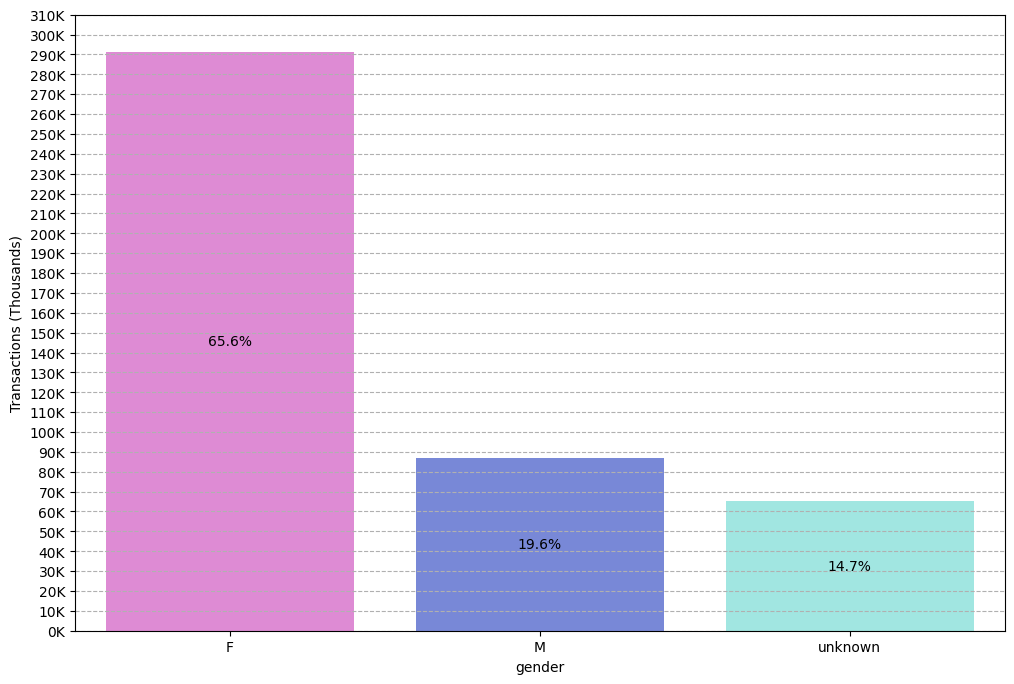

In [55]:
plt.figure(figsize=(12,8))

color_category = {
    "F": "#EC7DDF",
    "M": "#687DE7",
    "unknown": "#96F1EB"
}

ax = sns.countplot(
    data=df,
    x="gender",
    order=sorted(df["gender"].dropna().unique()),
    hue="gender",
    palette=color_category,
    legend=False
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

plt.yticks(np.arange(0,320000,10000))
plt.ylabel("Transactions (Thousands)")
plt.xlabel("gender")

plt.grid(linestyle="--",
        axis="y")

total = len(df)

for container in ax.containers:
    labels = [
        f"{(bar.get_height() / total) * 100:.1f}%"
        for bar in container
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="center"
    )

plt.show()

## Age Group

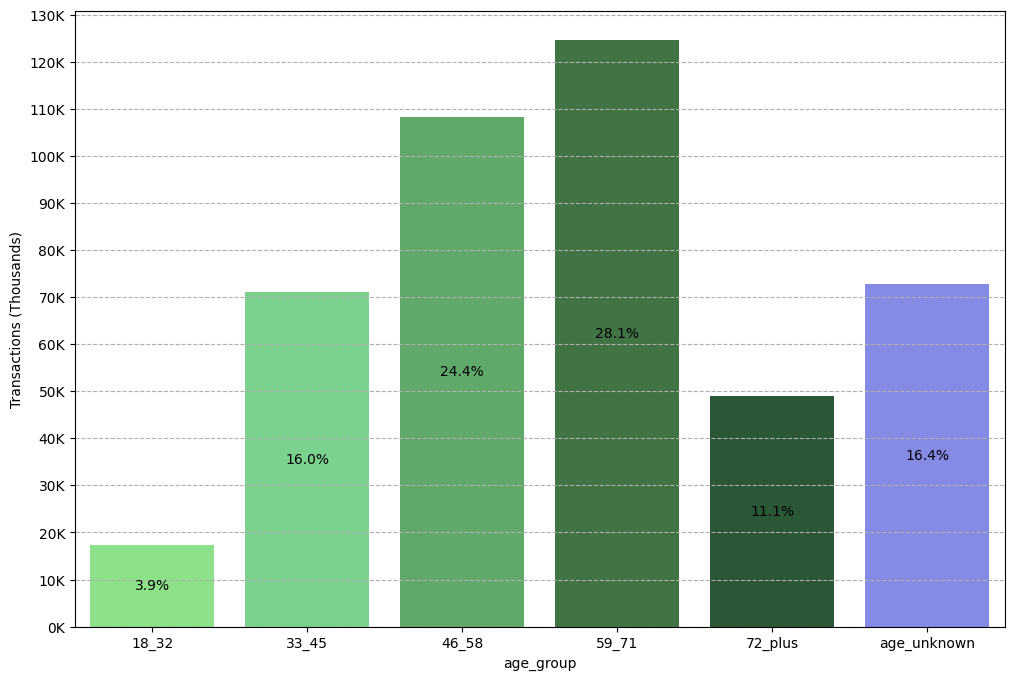

In [56]:
plt.figure(figsize=(12,8))

color_category = {
    "18_32": "#80F07A",
    "33_45": "#6DE087",
    "46_58": "#55B463",
    "59_71": "#387C3E",
    "72_plus": "#235F32",
    "age_unknown": "#757BF5"
}

ax = sns.countplot(
    data=df,
    x="age_group",
    order=sorted(df["age_group"].dropna().unique()),
    hue="age_group",
    palette=color_category,
    legend=False
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

plt.yticks(np.arange(0,140000,10000))
plt.ylabel("Transactions (Thousands)")
plt.xlabel("age_group")

plt.grid(linestyle="--",
        axis="y")

total = len(df)

for container in ax.containers:
    labels = [
        f"{(bar.get_height() / total) * 100:.1f}%"
        for bar in container
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="center"
    )

plt.show()

## Category

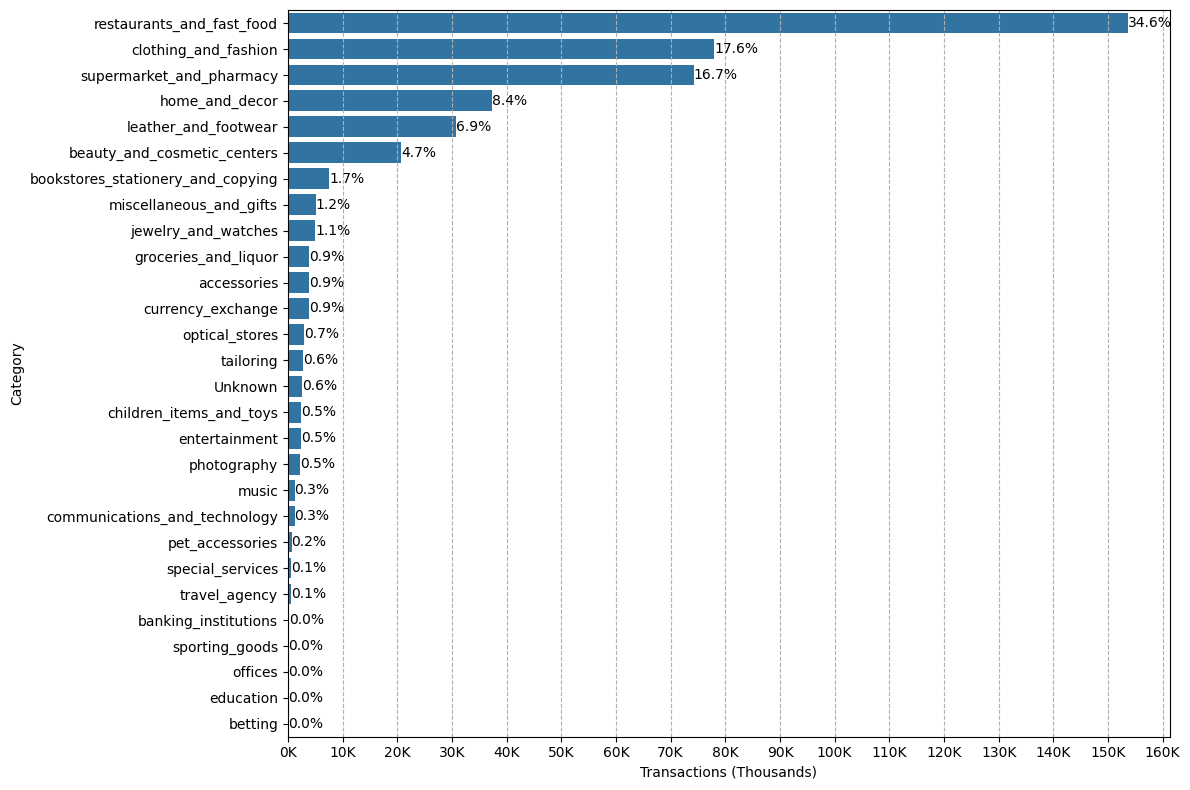

In [57]:
plt.figure(figsize=(12,8))

order = df["category"].value_counts().index

ax = sns.countplot(
    data=df,
    y="category",
    order=order
)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

plt.xticks(np.arange(0,170000,10000))

plt.xlabel("Transactions (Thousands)")
plt.ylabel("Category")

plt.grid(
    linestyle="--",
    axis="x"
)

total = len(df)

for container in ax.containers:
    labels = [
        f"{(bar.get_width() / total) * 100:.1f}%"
        for bar in container
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="edge"
    )

plt.tight_layout()
plt.show()

## Subcategory

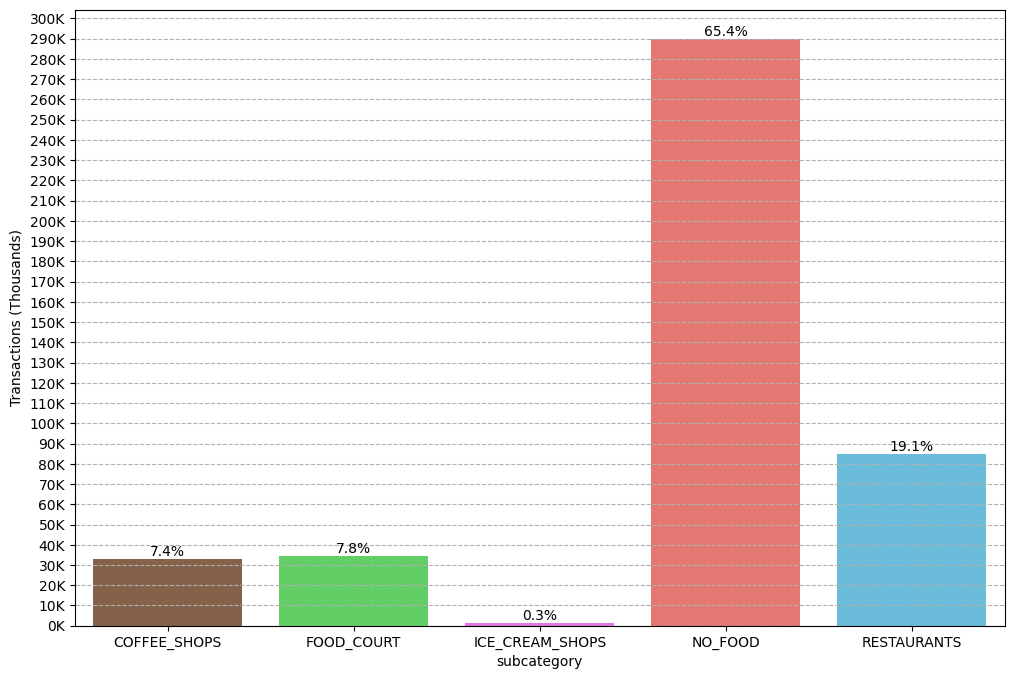

In [58]:
plt.figure(figsize=(12,8))

color_category = {
    "NO_FOOD": "#F6675F",
    "RESTAURANTS": "#59C3EC",
    "FOOD_COURT": "#50E055",
    "COFFEE_SHOPS": "#8E6040",
    "ICE_CREAM_SHOPS": "#EE69F3"}

ax = sns.countplot(
    data=df,
    x="subcategory",
    order=sorted(df["subcategory"].dropna().unique()),
    hue="subcategory",
    palette=color_category,
    legend=False
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

plt.yticks(np.arange(0,310000,10000))
plt.ylabel("Transactions (Thousands)")
plt.xlabel("subcategory")

plt.grid(linestyle="--",
        axis="y")

total = len(df)

for container in ax.containers:
    labels = [
        f"{(bar.get_height() / total) * 100:.1f}%"
        for bar in container
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="edge"
    )

plt.show()

## Day Week

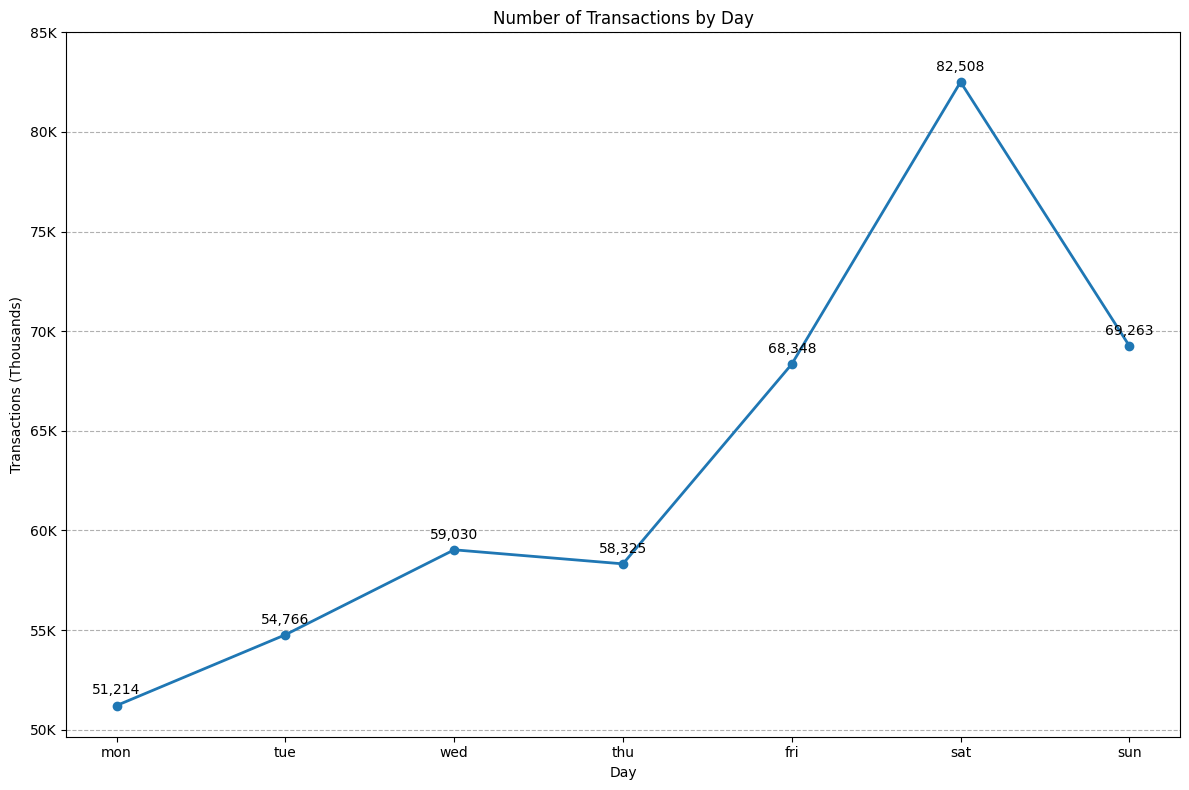

In [59]:
day_order = {
    "mon": 1,
    "tue": 2,
    "wed": 3,
    "thu": 4,
    "fri": 5,
    "sat": 6,
    "sun": 7
}

df["day_order"] = df["day_week"].map(day_order)

day_count = (
    df.groupby(["day_order", "day_week"])
    .size()
    .reset_index(name="count")
    .sort_values("day_order")
)

plt.figure(figsize=(12,8))

plt.plot(
    day_count["day_week"],
    day_count["count"],
    marker="o",
    linewidth=2
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

for x, y in zip(day_count["day_week"], day_count["count"]):
    plt.annotate(
        f"{y:,}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.yticks(np.arange(50000,90000,5000))
plt.xlabel("Day")
plt.ylabel("Transactions (Thousands)")
plt.title("Number of Transactions by Day")

plt.grid(
    linestyle="--",
    axis="y"
)

plt.tight_layout()
plt.show()

df = df.drop(columns="day_order")

## Month

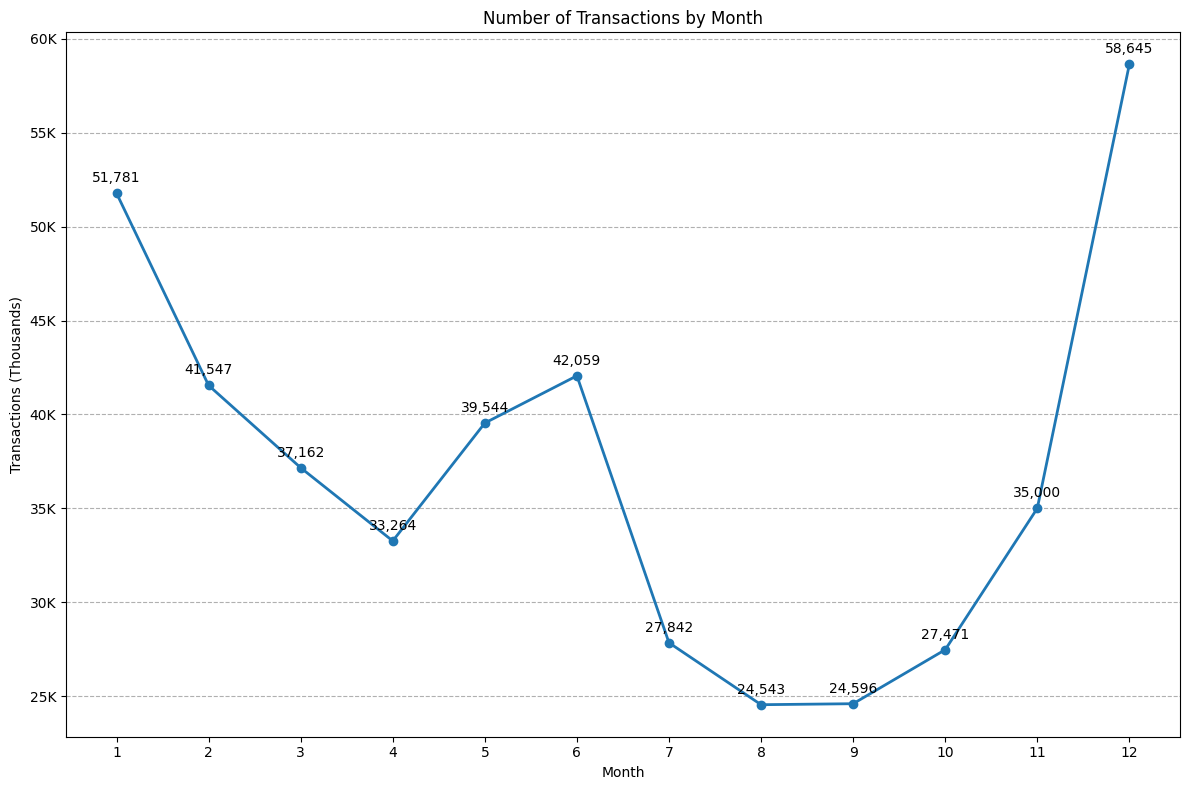

In [60]:
plt.figure(figsize=(12,8))

month_count = (
    df["month"]
    .value_counts()
    .sort_index()
)

plt.plot(
    month_count.index,
    month_count.values,
    marker="o",
    linewidth=2
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

plt.xticks(np.arange(1, 13))


for x, y in zip(month_count.index, month_count.values):
    plt.annotate(
        f"{y:,}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.xlabel("Month")
plt.ylabel("Transactions (Thousands)")
plt.title("Number of Transactions by Month")

plt.grid(
    linestyle="--",
    axis="y"
)

plt.tight_layout()
plt.show()

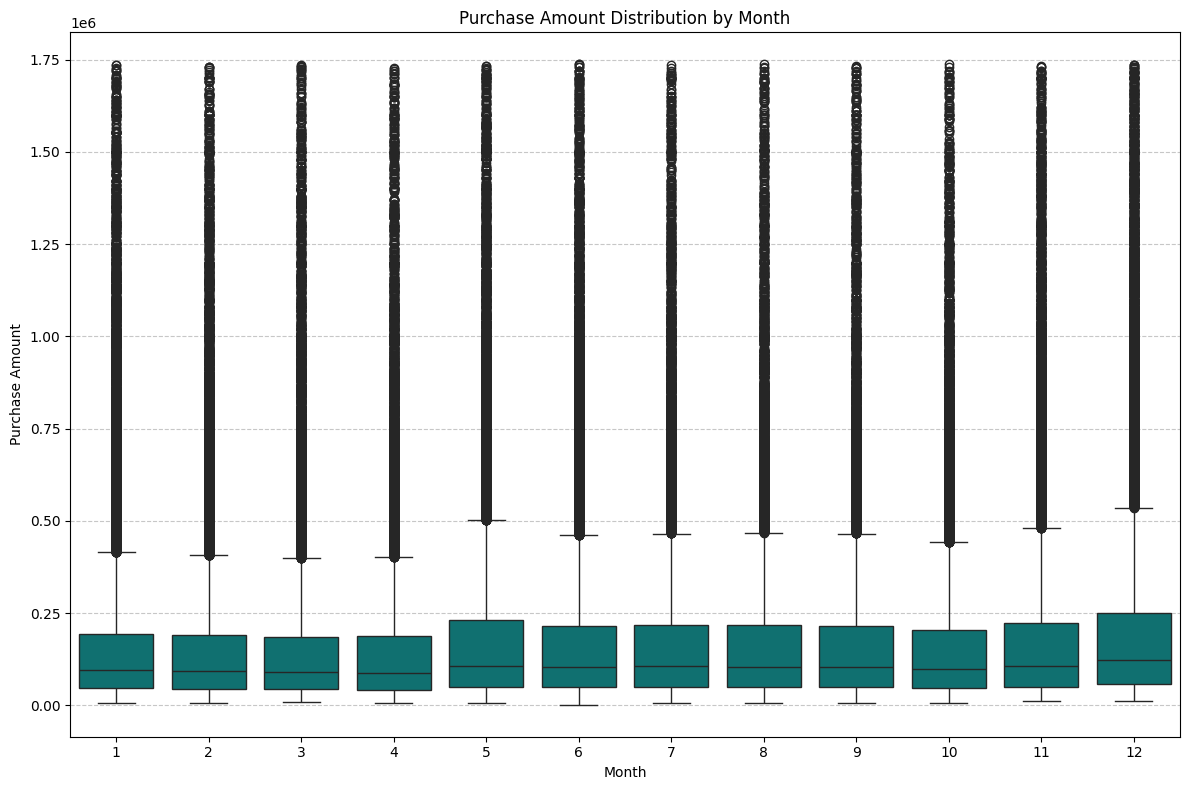

In [212]:
plt.figure(figsize=(12, 8))

sns.boxplot(
    data=df,
    x="month",
    y="purchase_amount",
    order=np.arange(1, 13),
    color="teal"
)

plt.xlabel("Month")
plt.ylabel("Purchase Amount")
plt.title("Purchase Amount Distribution by Month")

plt.grid(
    linestyle="--",
    axis="y",
    alpha=0.7
)

plt.tight_layout()
plt.show()

## EDA (Two Variables)

### Total

Since the important variable is purchase amount, we will conduct the exploration based on it.

#### Year - Purchase Amount

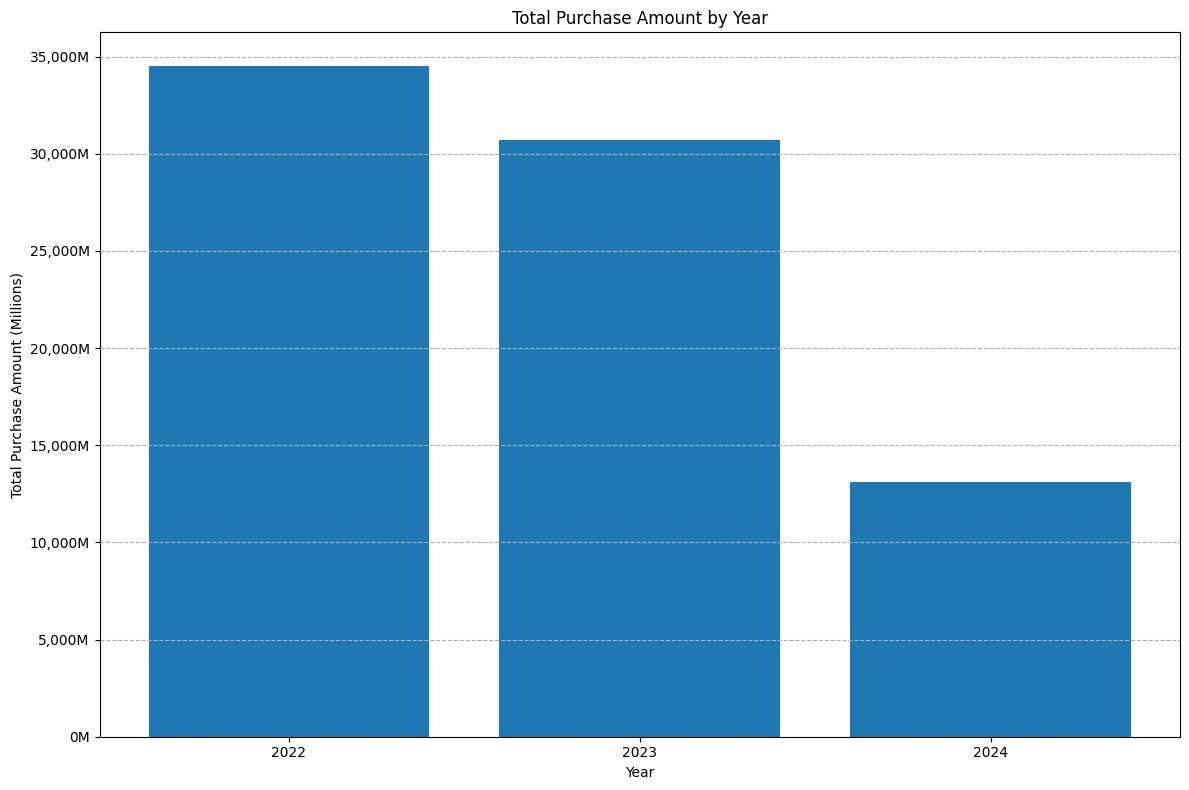

In [116]:
plt.figure(figsize=(12, 8))

year_total = (
    df.groupby("year")["purchase_amount"]
    .sum()
    .sort_index()
)

plt.bar(
    year_total.index,
    year_total.values / 1e6
)

plt.xlabel("Year")
plt.ylabel("Total Purchase Amount (Millions)")
plt.title("Total Purchase Amount by Year")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}M")
)

plt.grid(
    linestyle="--",
    axis="y"
)

plt.tight_layout()
plt.show()

#### Quarter - Purchase amount (by year)

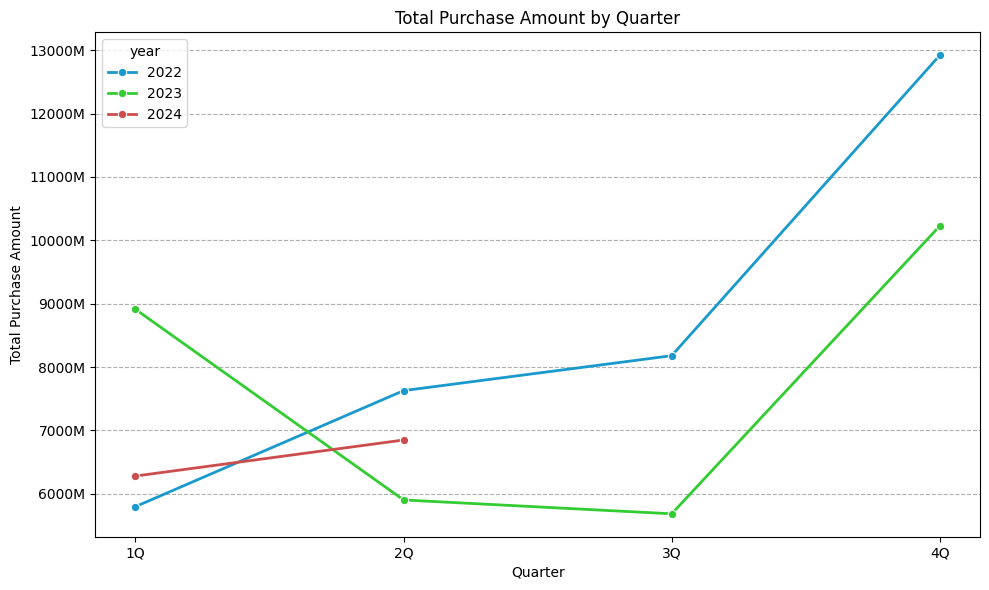

In [81]:
plt.figure(figsize=(10, 6))

order = ["1Q", "2Q", "3Q", "4Q"]

color_rgb = [
    "#1a99cc",
    "#33cc33",
    "#cc4d4d"
]


df_avg = (
    df.groupby(["quarter", "year"], as_index=False)["purchase_amount"]
      .sum()
)

sns.lineplot(
    data=df_avg,
    x="quarter",
    y="purchase_amount",
    hue="year",
    palette=color_rgb,
    marker="o",
    linewidth=2,
    errorbar=None,
    sort=False
)


plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000000:.0f}M")
)


plt.xticks(order)

plt.grid(
    linestyle="--",
    axis="y"
)

plt.xlabel("Quarter")
plt.ylabel("Total Purchase Amount")
plt.title("Total Purchase Amount by Quarter")

plt.tight_layout()
plt.show()

#### Month - Purchase by year

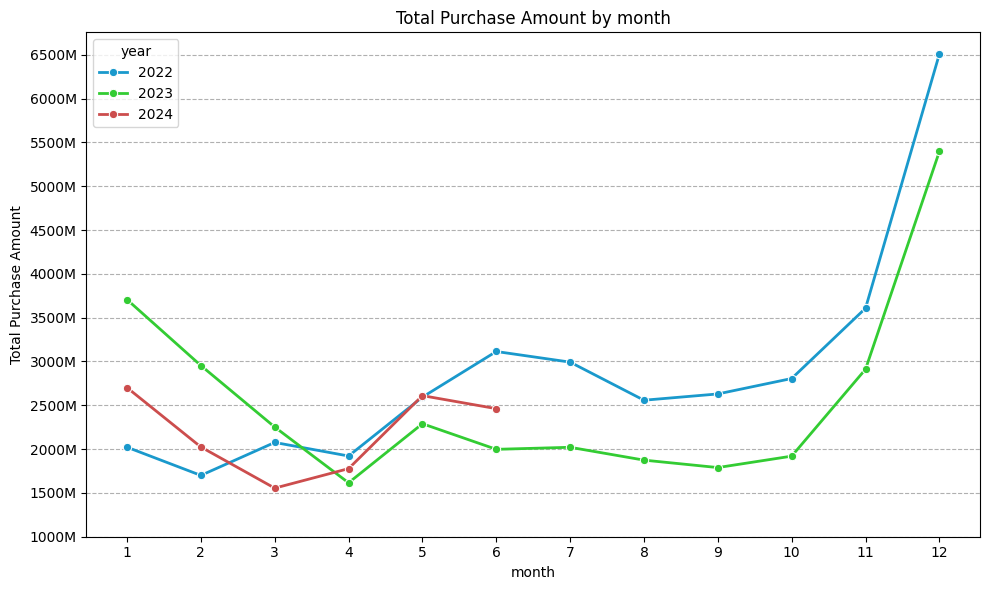

In [93]:
plt.figure(figsize=(10, 6))

color_rgb = [
    "#1a99cc",
    "#33cc33",
    "#cc4d4d"
]


df_avg = (
    df.groupby(["month", "year"], as_index=False)["purchase_amount"]
      .sum()
)

sns.lineplot(
    data=df_avg,
    x="month",
    y="purchase_amount",
    hue="year",
    palette=color_rgb,
    marker="o",
    linewidth=2,
    errorbar=None,
    sort=False
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000000:.0f}M")
)

plt.grid(
    linestyle="--",
    axis="y"
)

plt.xlabel("month")
plt.ylabel("Total Purchase Amount")
plt.title("Total Purchase Amount by month")
plt.xticks(np.arange(1,13,1))
plt.yticks(np.arange(1000000000,7000000000,500000000))

plt.tight_layout()
plt.show()

#### Gender - Purchase amount 

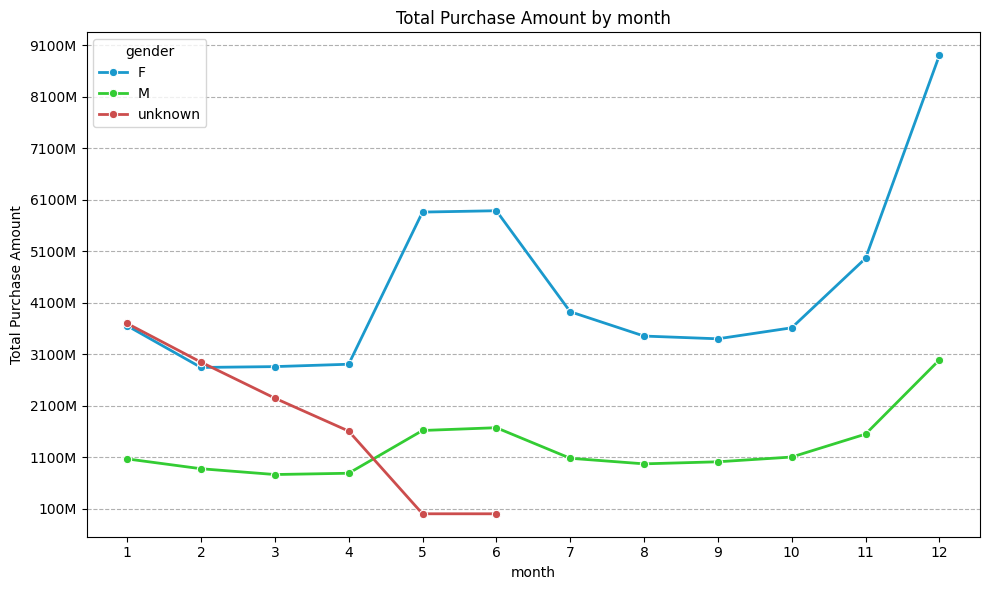

In [152]:
plt.figure(figsize=(10, 6))

color_rgb = [
    "#1a99cc",
    "#33cc33",
    "#cc4d4d"
]


df_avg = (
    df.groupby(["month", "gender"], as_index=False)["purchase_amount"]
      .sum()
)

sns.lineplot(
    data=df_avg,
    x="month",
    y="purchase_amount",
    hue="gender",
    palette=color_rgb,
    marker="o",
    linewidth=2,
    errorbar=None,
    sort=False
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000000:.0f}M")
)

plt.grid(
    linestyle="--",
    axis="y"
)

plt.xlabel("month")
plt.ylabel("Total Purchase Amount")
plt.title("Total Purchase Amount by month")
plt.xticks(np.arange(1,13,1))
plt.yticks(np.arange(100000000,10000000000,1000000000))

plt.tight_layout()
plt.show()

### Average

#### Month - Purchase by year

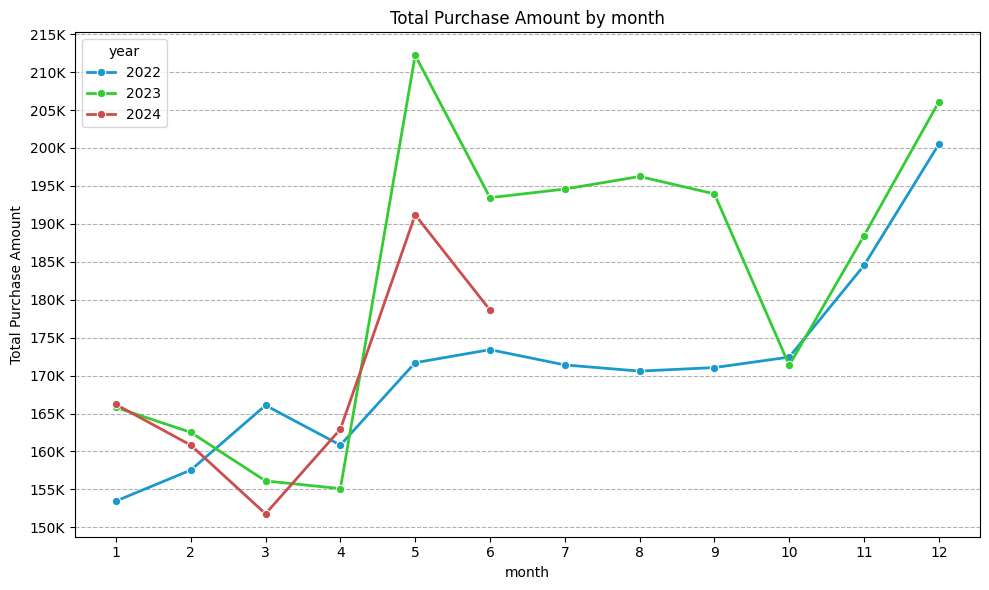

In [175]:
plt.figure(figsize=(10, 6))

color_rgb = [
    "#1a99cc",
    "#33cc33",
    "#cc4d4d"
]


df_avg = (
    df.groupby(["month", "year"], as_index=False)["purchase_amount"]
      .mean()
)

sns.lineplot(
    data=df_avg,
    x="month",
    y="purchase_amount",
    hue="year",
    palette=color_rgb,
    marker="o",
    linewidth=2,
    errorbar=None,
    sort=False
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

plt.grid(
    linestyle="--",
    axis="y"
)

plt.xlabel("month")
plt.ylabel("Total Purchase Amount")
plt.title("Total Purchase Amount by month")
plt.xticks(np.arange(1,13,1))
plt.yticks(np.arange(150000,220000,5000))

plt.tight_layout()
plt.show()

#### Gender - Purchase amount 

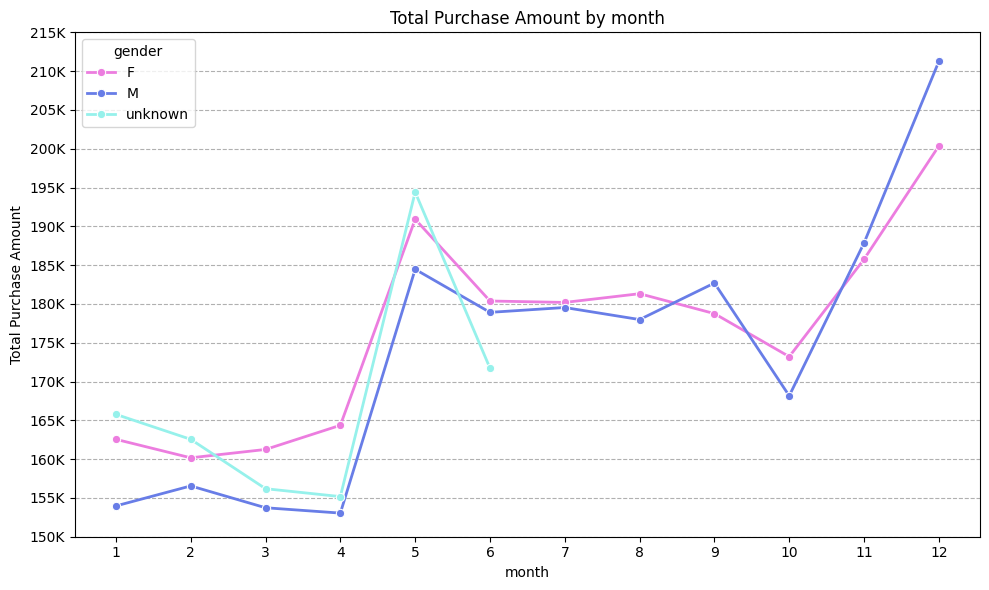

In [211]:
plt.figure(figsize=(10, 6))

color_category = {
    "F": "#EC7DDF",
    "M": "#687DE7",
    "unknown": "#96F1EB"
}

df_avg = (
    df.groupby(["month", "gender"], as_index=False)["purchase_amount"]
      .mean()
)

sns.lineplot(
    data=df_avg,
    x="month",
    y="purchase_amount",
    hue="gender",
    palette=color_category,
    marker="o",
    linewidth=2,
    errorbar=None,
    sort=False
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

plt.grid(
    linestyle="--",
    axis="y"
)

plt.xlabel("month")
plt.ylabel("Total Purchase Amount")
plt.title("Total Purchase Amount by month")
plt.xticks(np.arange(1,13,1))
plt.yticks(np.arange(150000,220000,5000))

plt.tight_layout()
plt.show()

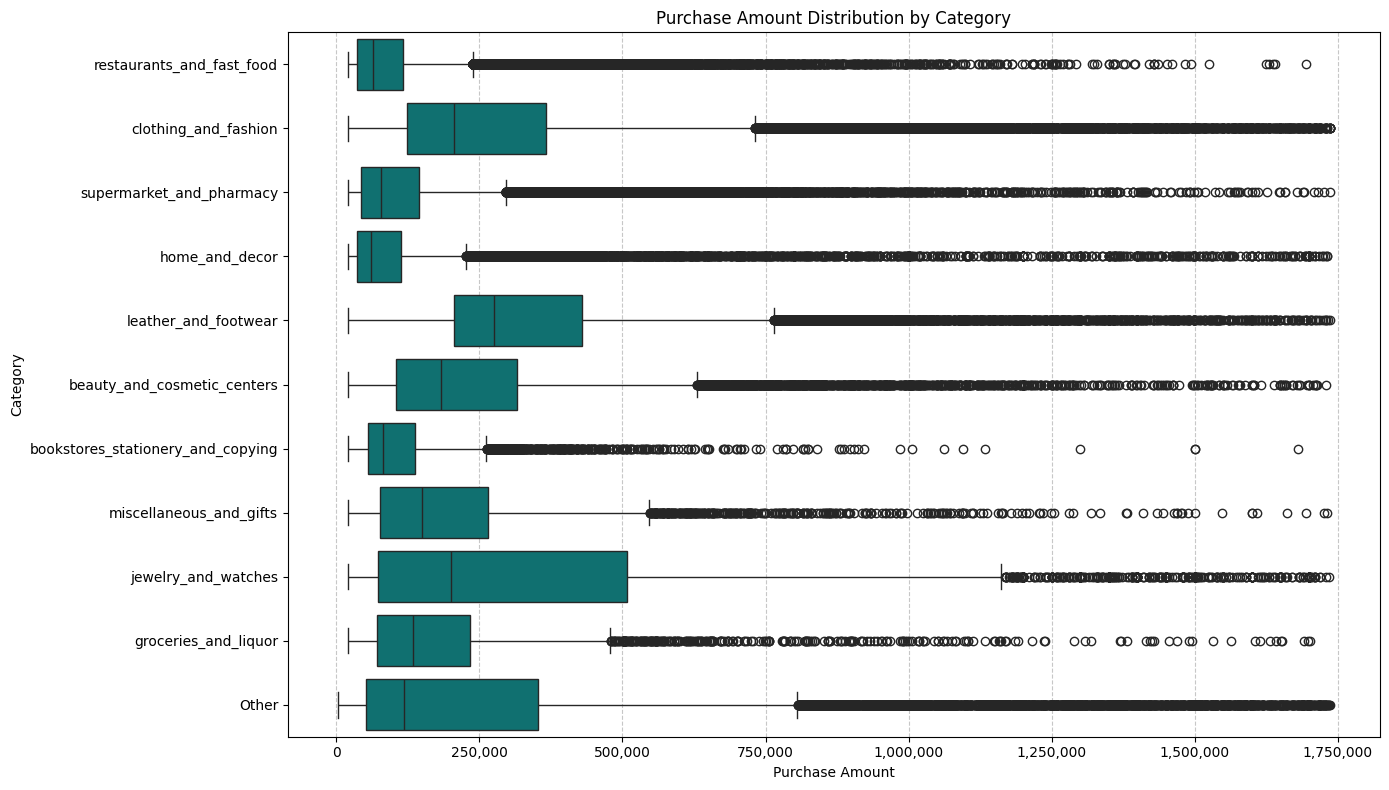

In [ ]:

top_10 = df["category"].value_counts().head(10).index

df_box = df.copy()

df_box["category_grouped"] = np.where(
    df_box["category"].isin(top_10),
    df_box["category"],
    "Other"
)

order = list(top_10) + ["Other"]

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df_box,
    y="category_grouped",
    x="purchase_amount",
    order=order,
    color="teal"
)

plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:,.0f}")
)

plt.xlabel("Purchase Amount")
plt.ylabel("Category")
plt.title("Purchase Amount Distribution by Category")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

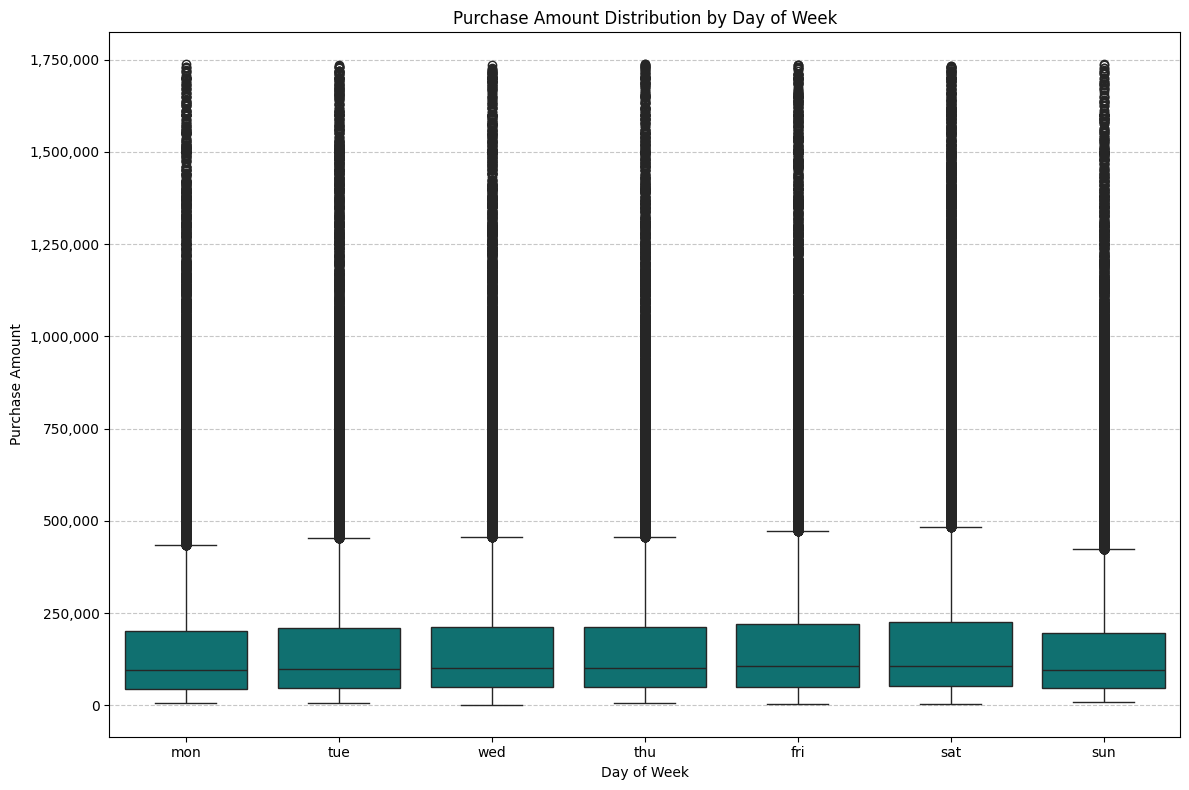

In [219]:
day_order = [
    "mon",
    "tue",
    "wed",
    "thu",
    "fri",
    "sat",
    "sun"
]

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=df,
    x="day_week",
    y="purchase_amount",
    order=day_order,
    color="teal"
)

plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:,.0f}")
)

plt.xlabel("Day of Week")
plt.ylabel("Purchase Amount")
plt.title("Purchase Amount Distribution by Day of Week")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()